# R0 F2 Batch Grid Scan

This notebook builds the same single-transition Lindblad problem used in the OBE benchmarks for `transitions.R0_F1_3o2_F2`, then runs a Rust-side batch `grid_scan`.

The scan uses angular units internally. The detuning axis is `2 * np.pi * detuning_MHz * 1e6` from `-10 MHz` to `+10 MHz`; the Rabi-rate axis is `2 * np.pi * rabi_MHz * 1e6` from `0.1 MHz` to `4 MHz`. The solver returns only final-time populations.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

import centrex_tlf
from centrex_tlf import couplings, lindblad, states, transitions
from centrex_tlf.lindblad import grid_scan, prepare_lindblad_problem

plt.rcParams.update({"font.size": 14})

print("cwd:", Path.cwd())
print("centrex_tlf:", centrex_tlf.__file__)

cwd: c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\examples\lindblad
centrex_tlf: c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\__init__.py


## Build the OBE System

The initial density matrix is spread uniformly over the `X, J=0` ground states selected from `system.QN`, so the indexing remains valid when `qn_compact=True`. The prepared Rust plan is built once; the parameter grid then only overrides the detuning and Rabi-rate base parameters in Rust.

In [2]:
setup_start = perf_counter()

QN_COMPACT = True

trans = transitions.R0_F1_3o2_F2
transition_selectors = couplings.generate_transition_selectors(
    [trans],
    [[couplings.polarization_Z]],
)
system = lindblad.generate_OBE_system_transitions(
    [trans], transition_selectors, method="matrix", qn_compact=QN_COMPACT
)

# Base values only define the default prepared plan. The grid scan overrides
# the selected detuning/Rabi slots for each trajectory without rebuilding it.
gamma = 2 * np.pi * 1.56e6
parameters = {str(symbol): 0.0 for symbol in system.H_symbolic.free_symbols}
for symbol in system.coupling_symbols:
    parameters[str(symbol)] = gamma
for group in system.polarization_symbols:
    for symbol in group if isinstance(group, (list, tuple)) else [group]:
        parameters[str(symbol)] = 1.0

n_states = len(system.QN)
ground_indices = np.array(
    [
        idx
        for idx, qn in enumerate(system.QN)
        if qn.largest.electronic_state == states.ElectronicState.X
    ],
    dtype=np.int64,
)
excited_indices = np.array(
    [
        idx
        for idx, qn in enumerate(system.QN)
        if qn.largest.electronic_state == states.ElectronicState.B
    ],
    dtype=np.int64,
)
j0_ground_indices = np.array(
    [idx for idx in ground_indices if system.QN[int(idx)].largest.J == 0],
    dtype=np.int64,
)
if j0_ground_indices.size == 0:
    raise RuntimeError("No X, J=0 states found in system.QN for initial population")

n_ground = int(ground_indices.size)
n_excited = int(excited_indices.size)
n_J0 = int(j0_ground_indices.size)
rho0 = np.zeros((n_states, n_states), dtype=np.complex128)
for idx in j0_ground_indices:
    rho0[int(idx), int(idx)] = 1.0 / n_J0

prepared = prepare_lindblad_problem(
    system,
    parameters,
    backend="rust",
    hamiltonian_representation="decomposed",
)

slot_names = list(prepared.parameter_graph["slot_names"])
selector = transition_selectors[0]
omega_name = str(getattr(selector, chr(0x03A9)))
delta_name = str(getattr(selector, chr(0x03B4)))
if omega_name not in slot_names or delta_name not in slot_names:
    raise RuntimeError(
        f"Could not find Rabi/detuning scan slots in {slot_names}; "
        f"got omega={omega_name!r}, delta={delta_name!r}"
    )
setup_seconds = perf_counter() - setup_start

print(
    {
        "n_states": n_states,
        "qn_compact": QN_COMPACT,
        "n_ground": n_ground,
        "n_excited": n_excited,
        "n_J0_ground": n_J0,
        "scan_slots": [delta_name, omega_name],
        "setup_seconds": setup_seconds,
    }
)

{'n_states': 11, 'qn_compact': True, 'n_ground': 6, 'n_excited': 5, 'n_J0_ground': 4, 'scan_slots': ['δ0', 'Ω0'], 'setup_seconds': 1.0347482000943273}


## Run the Grid Scan

`grid_scan` creates the Cartesian product of the detuning and Rabi-rate axes. For this notebook the returned array has shape `(n_detuning * n_rabi, n_states)` because `output_when="final"` and `output="populations"`. The next cell reshapes it back to `(n_detuning, n_rabi, n_states)` using `scan_result.metadata["grid_shape"]`.

In [3]:
t_span = (0.0, 20e-6)
n_detuning = 201
n_rabi = 201

detuning_MHz = np.linspace(-10.0, 10.0, n_detuning)
rabi_MHz = np.linspace(0.1, 4.0, n_rabi)

scan = {
    delta_name: 2 * np.pi * detuning_MHz * 1e6,
    omega_name: 2 * np.pi * rabi_MHz * 1e6,
}

solve_start = perf_counter()
scan_result = grid_scan(
    prepared,
    rho0,
    t_span,
    scan=scan,
    solver="dopri5_fast",
    execution_mode="expanded_sparse",
    output="populations",
    output_when="final",
    dense_output=False,
    dt=1e-10,
    reltol=1e-7,
    abstol=1e-9,
    parallel=True,
    collect_stats=True,
)
solve_seconds = perf_counter() - solve_start

final_population_grid = scan_result.values.reshape(
    *scan_result.metadata["grid_shape"],
    n_states,
)

print(
    {
        "trajectory_count": scan_result.trajectory_count,
        "values_shape": tuple(int(v) for v in scan_result.values.shape),
        "grid_shape": tuple(int(v) for v in scan_result.metadata["grid_shape"]),
        "final_population_grid_shape": tuple(int(v) for v in final_population_grid.shape),
        "wall_seconds": solve_seconds,
        "solver_stats": scan_result.solver_stats,
    }
)

{'trajectory_count': 40401, 'values_shape': (40401, 11), 'grid_shape': (201, 201), 'final_population_grid_shape': (201, 201, 11), 'wall_seconds': 6.315395600046031, 'solver_stats': {'solver': 'dopri5_fast_batch', 'rhs_calls': 100752501, 'jacobian_calls': 0, 'function_evaluations': 100752501, 'accepted_steps': 16772265, 'rejected_steps': 13085, 'internal_steps': 16785350, 'saved_points': 40401, 'setup_seconds': 0.2350628000000118, 'integration_seconds': 100.31015820000067, 'interpolation_seconds': 0.0, 'total_seconds': 6.3133654, 'rhs_seconds': 82.42607489999958, 'jacobian_seconds': 0.0, 'non_rhs_seconds': 0.0, 'average_rhs_seconds': 8.181045044231664e-07, 'average_jacobian_seconds': 0.0}}


## Inspect Final Populations

`final_population_grid[detuning_index, rabi_index, state_index]` contains the final-time population for each basis state. The first axis is detuning, the second axis is Rabi rate.

In [4]:
J0_total = final_population_grid[:, :, j0_ground_indices].sum(axis=-1)
ground_other_indices = np.setdiff1d(ground_indices, j0_ground_indices, assume_unique=True)
ground_other_total = final_population_grid[:, :, ground_other_indices].sum(axis=-1)

ground_total = final_population_grid[:, :, ground_indices].sum(axis=-1)
excited_total = final_population_grid[:, :, excited_indices].sum(axis=-1)
trace_grid = final_population_grid.sum(axis=-1)

print("trace range:", float(np.min(trace_grid)), float(np.max(trace_grid)))
print("ground range:", float(np.min(ground_total)), float(np.max(ground_total)))
print("excited range:", float(np.min(excited_total)), float(np.max(excited_total)))

example_detuning_index = len(detuning_MHz) // 2
example_rabi_index = len(rabi_MHz) // 2
final_population_grid[example_detuning_index, example_rabi_index]

trace range: 0.9999999999999978 1.0000000000000022
ground range: 0.9972364367910586 1.0000000117392336
excited range: -1.1739233024220427e-08 0.0027635632089414524


array([ 2.50000000e-01,  5.14504105e-11, -1.34472233e-10,  5.14504036e-11,
        7.49975382e-01,  2.46186479e-05,  0.00000000e+00, -4.22191322e-11,
       -6.18673596e-11, -4.22191291e-11,  0.00000000e+00])

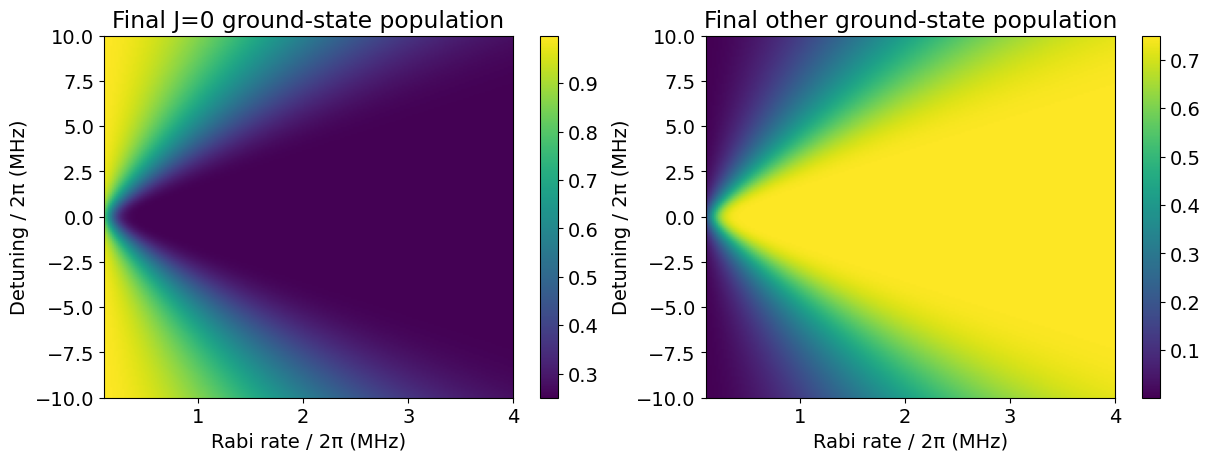

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
extent = [rabi_MHz[0], rabi_MHz[-1], detuning_MHz[0], detuning_MHz[-1]]

image0 = axes[0].imshow(
    J0_total,
    origin="lower",
    aspect="auto",
    extent=extent,
)
axes[0].set_title("Final J=0 ground-state population")
axes[0].set_xlabel("Rabi rate / 2π (MHz)")
axes[0].set_ylabel("Detuning / 2π (MHz)")
fig.colorbar(image0, ax=axes[0])

image1 = axes[1].imshow(
    ground_other_total,
    origin="lower",
    aspect="auto",
    extent=extent,
)
axes[1].set_title("Final other ground-state population")
axes[1].set_xlabel("Rabi rate / 2π (MHz)")
axes[1].set_ylabel("Detuning / 2π (MHz)")
fig.colorbar(image1, ax=axes[1])

plt.show()

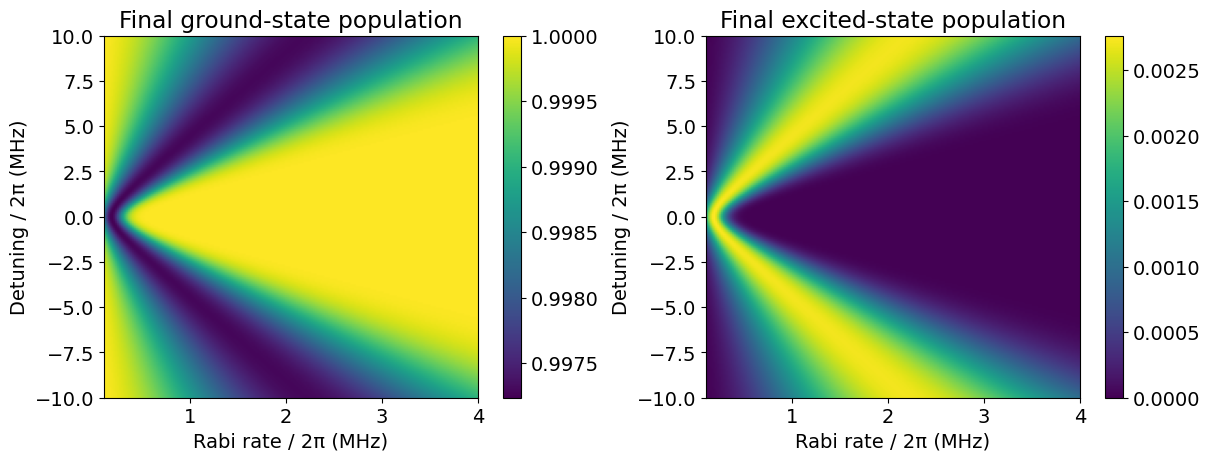

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
extent = [rabi_MHz[0], rabi_MHz[-1], detuning_MHz[0], detuning_MHz[-1]]

image0 = axes[0].imshow(
    ground_total,
    origin="lower",
    aspect="auto",
    extent=extent,
)
axes[0].set_title("Final ground-state population")
axes[0].set_xlabel("Rabi rate / 2π (MHz)")
axes[0].set_ylabel("Detuning / 2π (MHz)")
fig.colorbar(image0, ax=axes[0])

image1 = axes[1].imshow(
    excited_total,
    origin="lower",
    aspect="auto",
    extent=extent,
)
axes[1].set_title("Final excited-state population")
axes[1].set_xlabel("Rabi rate / 2π (MHz)")
axes[1].set_ylabel("Detuning / 2π (MHz)")
fig.colorbar(image1, ax=axes[1])

plt.show()

## Setup-Time Note

`grid_scan` now uses the compact Rust grid path. It sends one packed `rho0` plus the one-dimensional parameter axes to Rust; Rust maps each trajectory index to the corresponding grid coordinates internally. This avoids allocating a repeated `(n_trajectories, packed_len)` initial-state batch and avoids materializing the full Cartesian parameter table in Python.

The remaining setup time before CPU usage ramps up is mainly OBE system generation and `prepare_lindblad_problem`, not trajectory integration. The trajectory solve itself starts inside the Rust batch call and runs in parallel when `parallel=True`.
